# Prediksi Tarif Ongkos Naik Haji Kota Palu

## Menggunakan Metode Regresi Linear

Proyek ini bertujuan memprediksi tarif Ongkos Naik Haji Kota Palu tahun 2026–2028 berdasarkan data historis tahun 2021–2025.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from matplotlib.ticker import FuncFormatter

## Dataset

In [7]:
df = pd.read_csv("dataset_tarif_haji_palu.csv")
df

,Tahun,Tarif_Haji_Rp,Sumber
0,2021,37052602,BPS Kota Palu
1,2022,41362590,BPS Kota Palu
2,2023,50792201,BPS Kota Palu
3,2024,56510444,BPS Kota Palu
4,2025,57235421,BPS Kota Palu


## Pembuatan Model Regresi Linear

In [8]:
tahun = df["Tahun"].values.reshape(-1,1)
tarif = df["Tarif_Haji_Rp"].values

model = LinearRegression()
model.fit(tahun, tarif)

r2 = model.score(tahun, tarif)

print("Nilai R² =", round(r2,4))

Nilai R² = 0.9405


## Hasil Prediksi

In [9]:
prediksi_2026 = model.predict([[2026]])
prediksi_2027 = model.predict([[2027]])
prediksi_2028 = model.predict([[2028]])

print(f"Prediksi 2026 : Rp {prediksi_2026[0]:,.0f}")
print(f"Prediksi 2027 : Rp {prediksi_2027[0]:,.0f}")
print(f"Prediksi 2028 : Rp {prediksi_2028[0]:,.0f}")

Prediksi 2026 : Rp 65,244,699
Prediksi 2027 : Rp 70,796,048
Prediksi 2028 : Rp 76,347,398


## Visualisasi Grafik

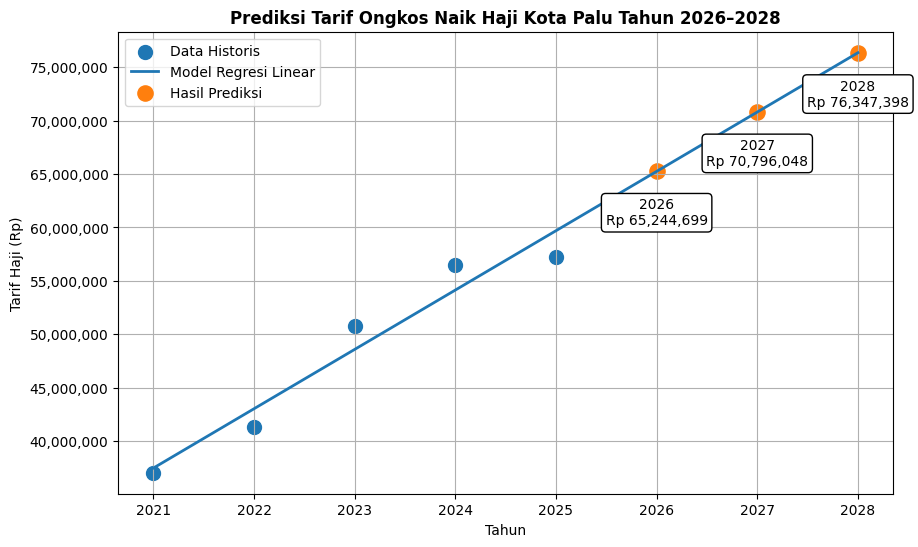

In [10]:
tahun_garis = np.array([
    2021,2022,2023,2024,
    2025,2026,2027,2028
]).reshape(-1,1)

prediksi_garis = model.predict(tahun_garis)

plt.figure(figsize=(10,6))

plt.scatter(
    tahun,
    tarif,
    s=100,
    label="Data Historis"
)

plt.plot(
    tahun_garis,
    prediksi_garis,
    linewidth=2,
    label="Model Regresi Linear"
)

plt.scatter(
    [2026,2027,2028],
    [
        prediksi_2026[0],
        prediksi_2027[0],
        prediksi_2028[0]
    ],
    s=120,
    label="Hasil Prediksi"
)

plt.annotate(
    f"2026\nRp {prediksi_2026[0]:,.0f}",
    (2026,prediksi_2026[0]),
    xytext=(2026,prediksi_2026[0]-5000000),
    ha="center",
    bbox=dict(boxstyle="round",fc="white")
)

plt.annotate(
    f"2027\nRp {prediksi_2027[0]:,.0f}",
    (2027,prediksi_2027[0]),
    xytext=(2027,prediksi_2027[0]-5000000),
    ha="center",
    bbox=dict(boxstyle="round",fc="white")
)

plt.annotate(
    f"2028\nRp {prediksi_2028[0]:,.0f}",
    (2028,prediksi_2028[0]),
    xytext=(2028,prediksi_2028[0]-5000000),
    ha="center",
    bbox=dict(boxstyle="round",fc="white")
)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x,p: f"{x:,.0f}")
)

plt.title(
    "Prediksi Tarif Ongkos Naik Haji Kota Palu Tahun 2026–2028",
    fontweight="bold"
)

plt.xlabel("Tahun")
plt.ylabel("Tarif Haji (Rp)")
plt.grid(True)
plt.legend()

plt.show()

## Kesimpulan

Berdasarkan hasil implementasi metode Regresi Linear menggunakan data tarif Ongkos Naik Haji Kota Palu tahun 2021–2025, diperoleh prediksi tarif haji sebesar:

- Tahun 2026 = Rp65.244.699
- Tahun 2027 = Rp70.796.048
- Tahun 2028 = Rp76.347.398

Hasil prediksi menunjukkan tren kenaikan tarif haji dari tahun ke tahun. Nilai R² yang tinggi menunjukkan bahwa model mampu menjelaskan sebagian besar variasi data historis yang digunakan.